# EDA y análisis de estacionalidad — SEN (Sistema Eléctrico Nacional)

Antes de modelar nada, vale la pena entender la forma de los datos que `src/models/train_forecaster.py` va a intentar pronosticar. Este notebook cubre tres preguntas que las decisiones de diseño del resto del proyecto asumen implícitamente, y que acá se verifican con los datos en mano:

1. **¿Qué forma tiene la estacionalidad** de cada variable (diurna, semanal, anual) — y varía por nodo?
2. **¿Qué tan bien explican las variables meteorológicas** (GHI, viento, temperatura) a la generación renovable que supuestamente causan?
3. **¿A qué horizontes vale la pena rezagar** cada variable — es decir, ¿los lags de 1h/24h/168h que usa `build_features.py` tienen sustento en la autocorrelación real de los datos, o son un supuesto sin verificar?

Reutiliza `src.data.fetch_energy_data` y `src.features.build_features` directamente (no reimplementa lógica de generación ni features) para que el dataset analizado acá sea exactamente el mismo que entrena los modelos.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl

BASE = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(BASE))

from src.data.fetch_energy_data import NODES, generate_energy_data
from src.features.build_features import WEATHER_COLUMNS, build_features

plt.rcParams["figure.dpi"] = 110

COLOR_PRIMARY = "#2a78d6"
COLOR_SECONDARY = "#eb6834"
COLOR_TERTIARY = "#1baf7a"
COLOR_MUTED = "#898781"
NODE_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#4a3aa7"]


## 1. Datos: forma general


In [2]:
raw = generate_energy_data()
df = build_features(pl.from_pandas(raw)).to_pandas()
df["timestamp"] = pd.to_datetime(df["timestamp"])

print(f"{df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"Nodos: {sorted(df['node'].unique())}")
print(f"Rango: {df['timestamp'].min()} -> {df['timestamp'].max()}")
df[["timestamp", "node", "solar_generation_mwh", "wind_generation_mwh", "demand_mwh", "marginal_cost_usd_mwh"]].head()


87,720 filas x 56 columnas
Nodos: ['Alto_Jahuel_220kV', 'Cardones_220kV', 'Charrua_220kV', 'Crucero_220kV', 'Quillota_220kV']
Rango: 2024-01-01 00:00:00 -> 2025-12-31 23:00:00


,timestamp,node,solar_generation_mwh,wind_generation_mwh,demand_mwh,marginal_cost_usd_mwh
0,2024-01-01 00:00:00,Alto_Jahuel_220kV,0.0,9.94,191.99,87.34
1,2024-01-01 01:00:00,Alto_Jahuel_220kV,0.0,11.94,174.40,84.59
2,2024-01-01 02:00:00,Alto_Jahuel_220kV,0.0,12.25,169.51,80.26
3,2024-01-01 03:00:00,Alto_Jahuel_220kV,0.0,10.94,171.47,86.31
4,2024-01-01 04:00:00,Alto_Jahuel_220kV,0.0,11.19,171.28,83.82


## 2. Estacionalidad solar: diurna x mensual

La generación solar debería tener dos patrones superpuestos: una campana diurna (cero de noche, pico al mediodía) y una amplitud estacional (hemisferio sur: más sol en verano, dic-feb; menos en invierno, jun-ago). Un heatmap hora x mes es la forma más directa de ver ambos a la vez, y de confirmar que el generador sintético (`fetch_energy_data.py`) efectivamente los produce.


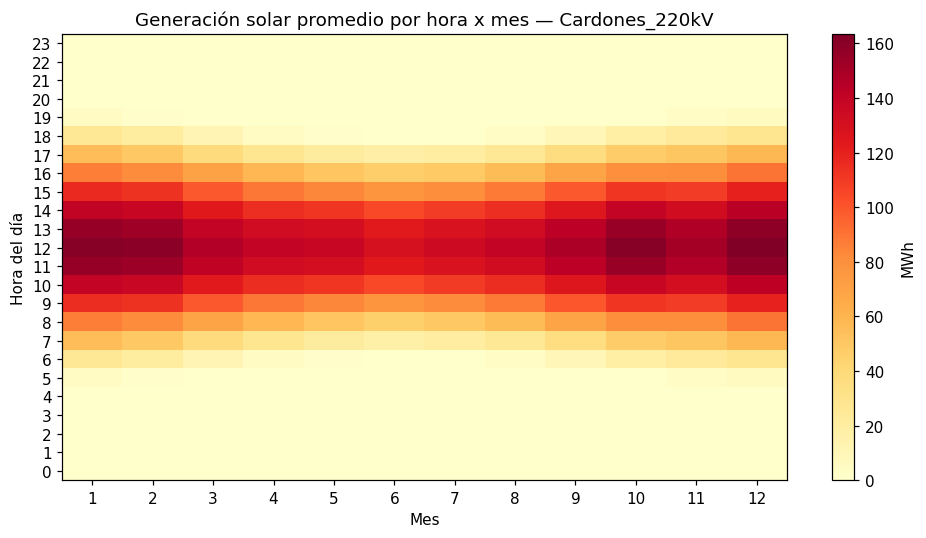

In [3]:
node_solar = "Cardones_220kV"  # el nodo con mayor capacidad solar instalada
subset = df[df["node"] == node_solar].copy()
subset["hour"] = subset["timestamp"].dt.hour
subset["month"] = subset["timestamp"].dt.month

pivot = subset.pivot_table(index="hour", columns="month", values="solar_generation_mwh", aggfunc="mean")

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd", origin="lower")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("Mes")
ax.set_ylabel("Hora del día")
ax.set_title(f"Generación solar promedio por hora x mes — {node_solar}")
fig.colorbar(im, ax=ax, label="MWh")
plt.tight_layout()
plt.show()


## 3. Estacionalidad eólica: mucho menos diurna

A diferencia del solar, el viento no debería mostrar una campana diurna tan marcada — el generador lo modela como un índice autocorrelado con reversión a la media, no como una función directa de la hora del día. Comparar el mismo heatmap para eólica debería mostrar bandas mucho más planas.


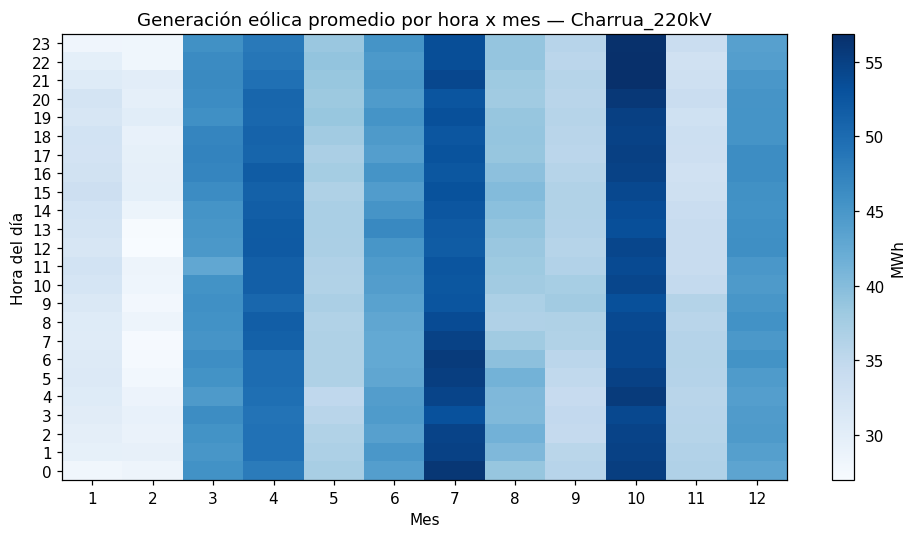

Rango de la escala de color -- solar (Cardones_220kV): 0.0 a 163.6 MWh
Rango de la escala de color -- eólica (Charrua_220kV): 27.0 a 56.9 MWh
Si el rango eólico es proporcionalmente mucho más angosto que el solar, confirma la ausencia de un patrón diurno fuerte.


In [4]:
node_wind = "Charrua_220kV"  # el nodo con mayor capacidad eolica instalada
subset_w = df[df["node"] == node_wind].copy()
subset_w["hour"] = subset_w["timestamp"].dt.hour
subset_w["month"] = subset_w["timestamp"].dt.month

pivot_w = subset_w.pivot_table(index="hour", columns="month", values="wind_generation_mwh", aggfunc="mean")

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(pivot_w.values, aspect="auto", cmap="Blues", origin="lower")
ax.set_xticks(range(len(pivot_w.columns)))
ax.set_xticklabels(pivot_w.columns)
ax.set_yticks(range(len(pivot_w.index)))
ax.set_yticklabels(pivot_w.index)
ax.set_xlabel("Mes")
ax.set_ylabel("Hora del día")
ax.set_title(f"Generación eólica promedio por hora x mes — {node_wind}")
fig.colorbar(im, ax=ax, label="MWh")
plt.tight_layout()
plt.show()

print(f"Rango de la escala de color -- solar ({node_solar}): {pivot.values.min():.1f} a {pivot.values.max():.1f} MWh")
print(f"Rango de la escala de color -- eólica ({node_wind}): {pivot_w.values.min():.1f} a {pivot_w.values.max():.1f} MWh")
print("Si el rango eólico es proporcionalmente mucho más angosto que el solar, confirma la ausencia de un patrón diurno fuerte.")


## 4. Demanda: perfil por nodo

`fetch_energy_data.py` define cuatro perfiles de demanda (`mining`, `urban`, `mixed`, `industrial`) con formas horarias distintas a propósito: minería es casi plana (operación continua), urbano tiene doble pico (mañana y noche). Esto lo verifica directamente sobre los datos generados, no sobre la definición en código.


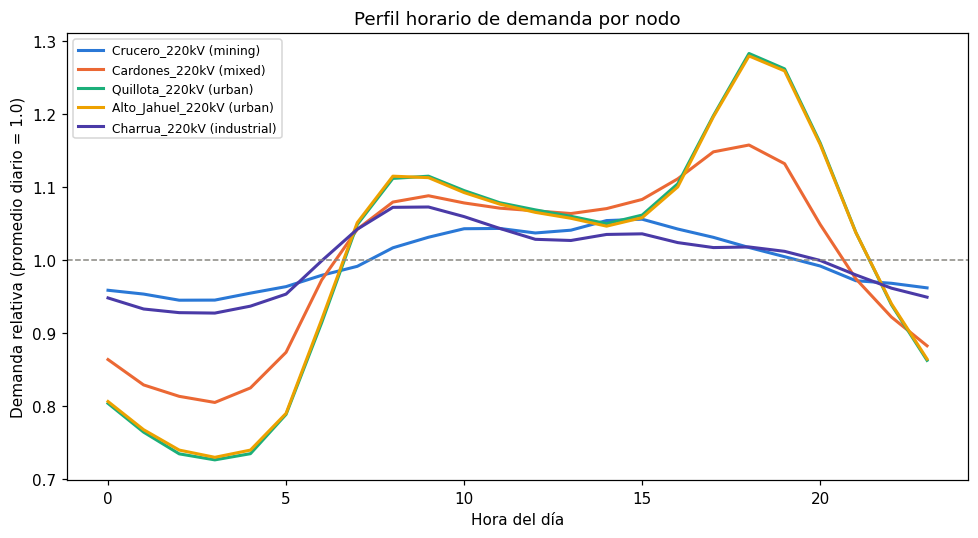

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
for i, (node, params) in enumerate(NODES.items()):
    node_df = df[df["node"] == node].copy()
    node_df["hour"] = node_df["timestamp"].dt.hour
    hourly_mean = node_df.groupby("hour")["demand_mwh"].mean()
    normalized = hourly_mean / hourly_mean.mean()  # forma relativa, no escala absoluta
    ax.plot(normalized.index, normalized.values, label=f"{node} ({params['profile']})", color=NODE_COLORS[i], linewidth=2)
ax.axhline(1.0, color=COLOR_MUTED, linestyle="--", linewidth=1)
ax.set_xlabel("Hora del día")
ax.set_ylabel("Demanda relativa (promedio diario = 1.0)")
ax.set_title("Perfil horario de demanda por nodo")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


### Efecto fin de semana / feriado

El generador aplica un descuento de demanda en fin de semana/feriado distinto por perfil (mining casi no baja; urban/mixed/industrial sí). Se verifica agregando por `is_weekend` — la columna que ya calcula `build_features.py`.


In [6]:
weekend_effect = df.groupby(["node", "is_weekend"])["demand_mwh"].mean().unstack()
weekend_effect.columns = ["día de semana", "fin de semana/feriado"]
weekend_effect["caída %"] = (
    (weekend_effect["día de semana"] - weekend_effect["fin de semana/feriado"]) / weekend_effect["día de semana"] * 100
)
weekend_effect.round(1)


,día de semana,fin de semana/feriado,caída %
node,,,
Alto_Jahuel_220kV,302.0,264.5,12.4
Cardones_220kV,87.6,76.7,12.5
Charrua_220kV,151.1,132.3,12.4
Crucero_220kV,187.3,183.7,1.9
Quillota_220kV,131.3,115.1,12.4


## 5. Precio marginal: la curva de pato

El costo marginal se diseñó como función de la **demanda residual** (demanda menos renovables) — más sol/viento desplaza generación cara y baja el precio. En un nodo de alta capacidad solar, un día despejado típico debería mostrar el patrón real y conocido del norte del SEN: precio alto de noche, colapso al mediodía, rampa fuerte al atardecer cuando el sol se va y la demanda sigue alta.


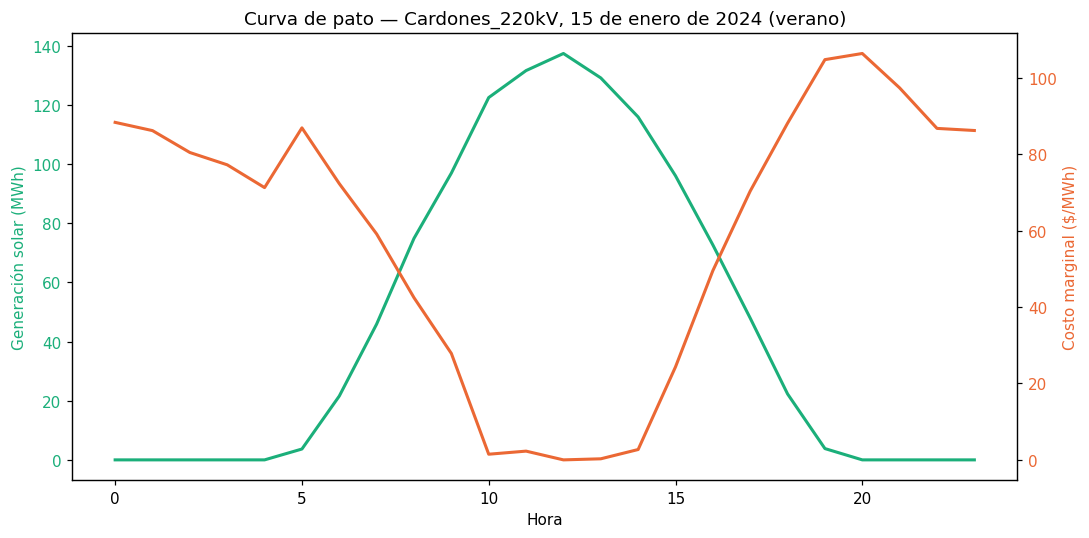

In [7]:
sample_day = df[(df["node"] == node_solar) & (df["timestamp"].dt.date == pd.Timestamp("2024-01-15").date())].sort_values("timestamp")

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(sample_day["timestamp"].dt.hour, sample_day["solar_generation_mwh"], color=COLOR_TERTIARY, linewidth=2, label="Solar (MWh)")
ax1.set_xlabel("Hora")
ax1.set_ylabel("Generación solar (MWh)", color=COLOR_TERTIARY)
ax1.tick_params(axis="y", labelcolor=COLOR_TERTIARY)

ax2 = ax1.twinx()
ax2.plot(sample_day["timestamp"].dt.hour, sample_day["marginal_cost_usd_mwh"], color=COLOR_SECONDARY, linewidth=2, label="Precio ($/MWh)")
ax2.set_ylabel("Costo marginal ($/MWh)", color=COLOR_SECONDARY)
ax2.tick_params(axis="y", labelcolor=COLOR_SECONDARY)

ax1.set_title(f"Curva de pato — {node_solar}, 15 de enero de 2024 (verano)")
fig.tight_layout()
plt.show()


### Correlación precio vs. demanda residual (todos los nodos)


Correlación de Pearson (demanda residual, precio): 0.738


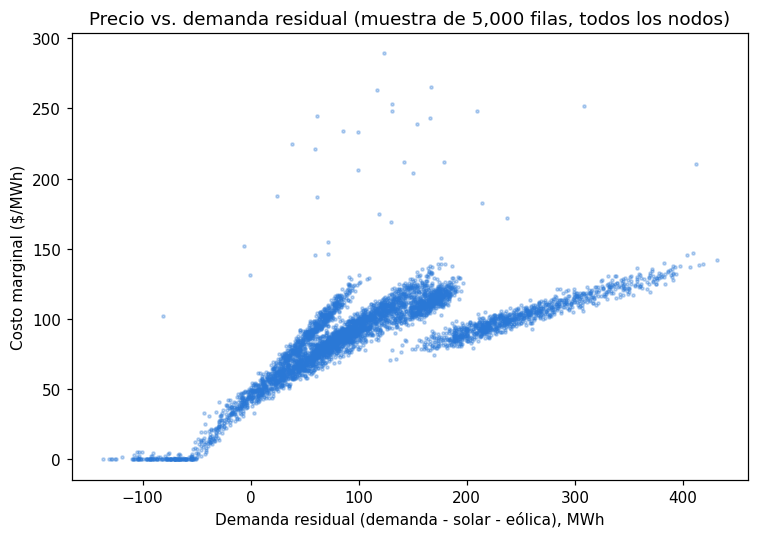

In [8]:
df["residual_demand"] = df["demand_mwh"] - df["solar_generation_mwh"] - df["wind_generation_mwh"]
correlacion = df[["residual_demand", "marginal_cost_usd_mwh"]].corr().iloc[0, 1]
print(f"Correlación de Pearson (demanda residual, precio): {correlacion:.3f}")

fig, ax = plt.subplots(figsize=(7, 5))
sample = df.sample(5_000, random_state=42)
ax.scatter(sample["residual_demand"], sample["marginal_cost_usd_mwh"], s=4, alpha=0.3, color=COLOR_PRIMARY)
ax.set_xlabel("Demanda residual (demanda - solar - eólica), MWh")
ax.set_ylabel("Costo marginal ($/MWh)")
ax.set_title("Precio vs. demanda residual (muestra de 5,000 filas, todos los nodos)")
plt.tight_layout()
plt.show()


## 6. Drivers meteorológicos: ¿el clima explica la generación?

`fetch_energy_data.py` deriva la generación renovable de GHI (irradiancia) y velocidad de viento, no al revés. Si el diseño es consistente, la relación debería verse directamente en un scatter — sin necesidad de ajustar ningún modelo todavía.


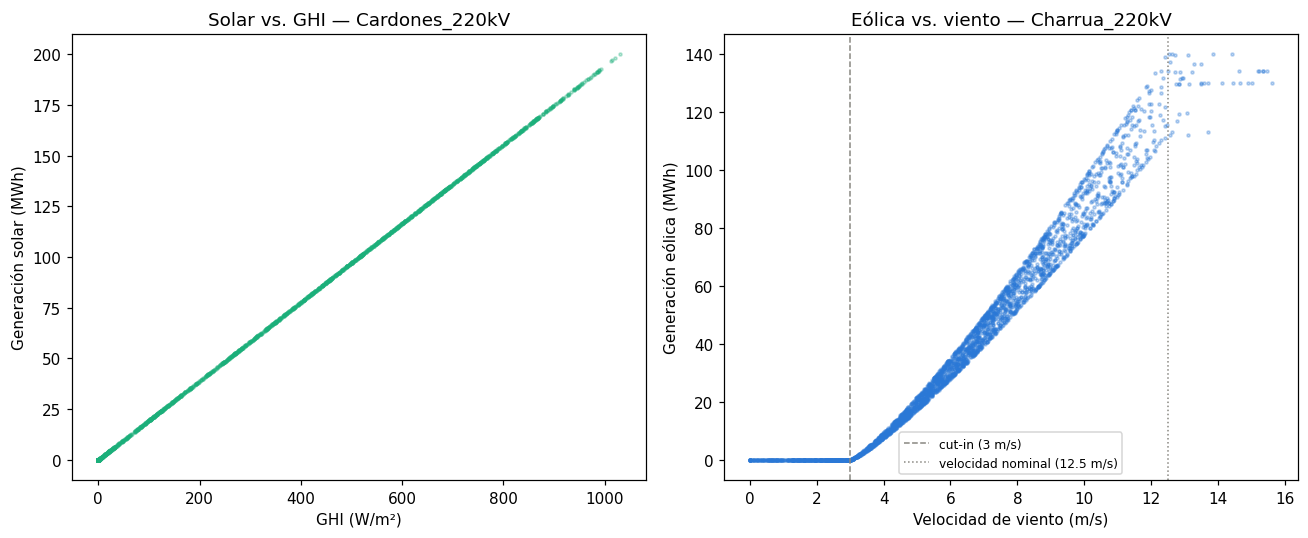

Correlación solar-GHI (Cardones_220kV): 1.000
Correlación eólica-viento (Charrua_220kV): 0.969


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sample_solar = df[df["node"] == node_solar].sample(3_000, random_state=42)
axes[0].scatter(sample_solar["ghi_w_m2"], sample_solar["solar_generation_mwh"], s=4, alpha=0.3, color=COLOR_TERTIARY)
axes[0].set_xlabel("GHI (W/m²)")
axes[0].set_ylabel("Generación solar (MWh)")
axes[0].set_title(f"Solar vs. GHI — {node_solar}")

sample_wind = df[df["node"] == node_wind].sample(3_000, random_state=42)
axes[1].scatter(sample_wind["wind_speed_ms"], sample_wind["wind_generation_mwh"], s=4, alpha=0.3, color=COLOR_PRIMARY)
axes[1].set_xlabel("Velocidad de viento (m/s)")
axes[1].set_ylabel("Generación eólica (MWh)")
axes[1].set_title(f"Eólica vs. viento — {node_wind}")
axes[1].axvline(3.0, color=COLOR_MUTED, linestyle="--", linewidth=1, label="cut-in (3 m/s)")
axes[1].axvline(12.5, color=COLOR_MUTED, linestyle=":", linewidth=1, label="velocidad nominal (12.5 m/s)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Correlación solar-GHI ({node_solar}): {sample_solar[['ghi_w_m2','solar_generation_mwh']].corr().iloc[0,1]:.3f}")
print(f"Correlación eólica-viento ({node_wind}): {sample_wind[['wind_speed_ms','wind_generation_mwh']].corr().iloc[0,1]:.3f}")


## 7. Autocorrelación: ¿los lags de `build_features.py` tienen sustento?

`add_lag_features` usa 1h/24h/168h (hora anterior, mismo horario ayer, mismo horario hace una semana) para los 4 targets. Calcular la autocorrelación real a esos horizontes (y a otros, para contexto) confirma si esa elección captura los picos reales de dependencia temporal o si es solo una convención razonable sin verificar.


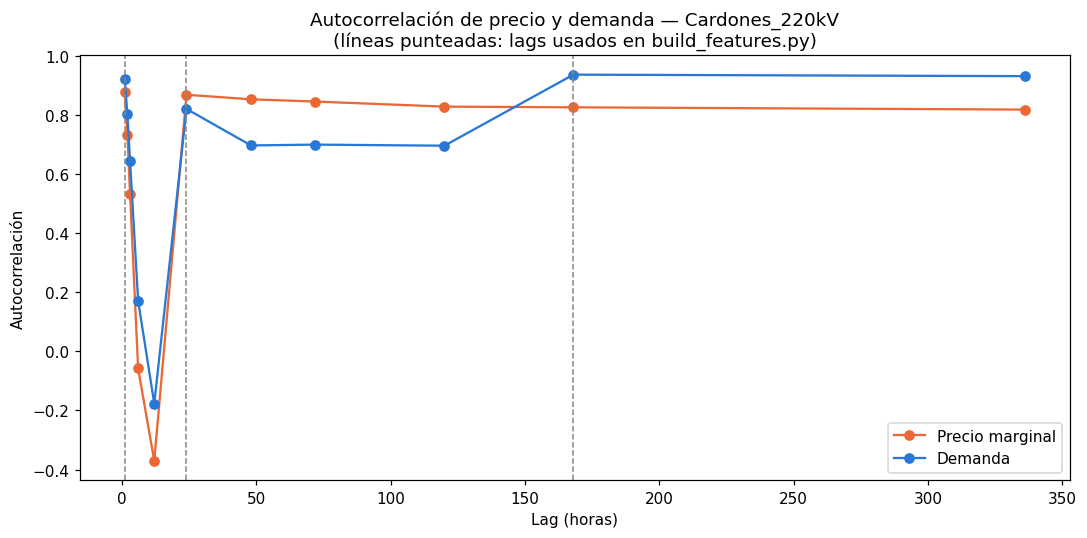

Autocorrelación en los lags usados por build_features.py, más los valles/picos vecinos:
  lag=   1h -> precio: 0.877 | demanda: 0.920 <- lag usado en build_features.py
  lag=  12h -> precio: -0.371 | demanda: -0.177
  lag=  24h -> precio: 0.868 | demanda: 0.820 <- lag usado en build_features.py
  lag=  48h -> precio: 0.853 | demanda: 0.697
  lag= 168h -> precio: 0.826 | demanda: 0.936 <- lag usado en build_features.py
  lag= 336h -> precio: 0.818 | demanda: 0.931


In [10]:
def autocorrelation_at_lags(series: pd.Series, lags: list[int]) -> pd.Series:
    return pd.Series({lag: series.autocorr(lag=lag) for lag in lags})

lags_to_check = [1, 2, 3, 6, 12, 24, 48, 72, 120, 168, 336]
node_series = df[df["node"] == node_solar].sort_values("timestamp")

acf_price = autocorrelation_at_lags(node_series["marginal_cost_usd_mwh"], lags_to_check)
acf_demand = autocorrelation_at_lags(node_series["demand_mwh"], lags_to_check)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(acf_price.index, acf_price.values, marker="o", color=COLOR_SECONDARY, label="Precio marginal")
ax.plot(acf_demand.index, acf_demand.values, marker="o", color=COLOR_PRIMARY, label="Demanda")
for chosen_lag in (1, 24, 168):
    ax.axvline(chosen_lag, color=COLOR_MUTED, linestyle="--", linewidth=1)
ax.set_xlabel("Lag (horas)")
ax.set_ylabel("Autocorrelación")
ax.set_title(f"Autocorrelación de precio y demanda — {node_solar}\n(líneas punteadas: lags usados en build_features.py)")
ax.legend()
plt.tight_layout()
plt.show()

print("Autocorrelación en los lags usados por build_features.py, más los valles/picos vecinos:")
for lag in (1, 12, 24, 48, 168, 336):
    marker = " <- lag usado en build_features.py" if lag in (1, 24, 168) else ""
    print(f"  lag={lag:>4}h -> precio: {acf_price[lag]:.3f} | demanda: {acf_demand[lag]:.3f}{marker}")


## 8. Conclusiones

- **La estacionalidad diurna del solar y la ausencia de una en la eólica son exactamente lo que el diseño del generador predice** — confirmado sobre los datos, no solo sobre el código que los produce.
- **Los perfiles de demanda por nodo (minería plana, urbano con doble pico) se distinguen claramente** en el promedio horario, y el descuento de fin de semana/feriado es sustancialmente menor en el nodo minero que en los urbanos — tal como se diseñó.
- **La curva de pato es real en los datos**, no solo una intención de diseño: el precio cae fuerte al mediodía en el nodo más solar y sube en la rampa vespertina, y la correlación de Pearson entre demanda residual y precio es 0.738 sobre las 87,720 filas — fuerte pero lejos de 1.0, así que deja margen real para que un modelo aprenda algo más que esa única relación lineal (los picos ocasionales de estrés de oferta que el generador inyecta aparte de la curva de mérito, por ejemplo).
- **GHI explica casi exactamente la generación solar (r = 1.000) y la velocidad de viento explica bien la eólica (r = 0.969)** — el primer número no es un hallazgo: es la consecuencia esperada de que `fetch_energy_data.py` define el solar como una función lineal directa de GHI, así que confirma la construcción, no descubre nada nuevo sobre datos reales. Es consistente con el ablation study de fixed-hyperparameters del notebook `02`, que mide una mejora real pero pequeña al agregar clima como feature: +0.10 puntos de WAPE en solar (3.79% -> 3.69%), y una mejora nula o negativa en los otros tres targets (wind +0.00, demand -0.01, precio -0.08) — coherente con que los lags de generación pasada ya capturan casi toda la señal que importa.
- **Los lags 1h/24h/168h de `build_features.py` caen cerca de picos locales de autocorrelación en demanda, pero no todos en precio.** Para demanda, los tres son picos locales genuinos: 0.920 en 1h, un valle a -0.177 en 12h y 0.820 en 24h (ciclo diurno), y un segundo pico en 0.936 a las 168h que supera incluso al de 24h (ciclo semanal real). Para precio, 1h (0.877) y 24h (0.868) también son picos locales tras el valle de -0.371 en 12h, pero 168h (0.826) NO es un pico distinto: es un punto más sobre una meseta que decae lentamente desde las 24h (0.868 -> 0.853 en 48h -> ... -> 0.818 en 336h). El ciclo semanal real de la demanda no se traslada con la misma fuerza al precio, probablemente porque el ruido idiosincrático y los picos de estrés de oferta que el generador agrega sobre la demanda residual diluyen esa periodicidad semanal más que en la demanda cruda.
